<a href="https://colab.research.google.com/github/sandro-silva/Data/blob/master/modelo_classificador_de_tumores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import numpy as np
import pandas as pd

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
df = pd.read_csv('/content/drive/MyDrive/Aprendizagem de Máquina/data.csv',
                    sep=',', encoding='utf-8')

In [58]:
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [59]:
df.columns

Index(['image_name', 'patient_id', 'sex', 'age_approx',
       'anatom_site_general_challenge', 'diagnosis', 'benign_malignant',
       'target'],
      dtype='object')

In [63]:
df.isnull().sum()

,0
image_name,0
patient_id,0
sex,65
age_approx,68
anatom_site_general_challenge,527
diagnosis,0
benign_malignant,0
target,0


In [61]:
df.dtypes

,0
image_name,object
patient_id,object
sex,object
age_approx,float64
anatom_site_general_challenge,object
diagnosis,object
benign_malignant,object
target,int64


In [64]:
df['target'].value_counts()

,count
target,
0,32542
1,584


In [60]:
df.shape

(33126, 8)

In [67]:
df['sex'].value_counts()

,count
sex,
male,17080
female,15981


In [68]:
df['age_approx'].value_counts()

,count
age_approx,
45.0,4466
50.0,4270
55.0,3824
40.0,3576
60.0,3240
35.0,2850
65.0,2527
30.0,2358
70.0,1968


In [69]:
df['anatom_site_general_challenge'].value_counts()

,count
anatom_site_general_challenge,
torso,16845
lower extremity,8417
upper extremity,4983
head/neck,1855
palms/soles,375
oral/genital,124


**Análises Estatísticas Descritivas**

In [71]:
df.describe()

,age_approx,target
count,33058.000000,33126.000000
mean,48.870016,0.017630
std,14.380360,0.131603
min,0.000000,0.000000
25%,40.000000,0.000000
50%,50.000000,0.000000
75%,60.000000,0.000000
max,90.000000,1.000000


**Transformando as variáveis categóricas nominais em variáveis categóricas ordinais**

In [72]:
df2 = pd.DataFrame.copy(df)

In [75]:
# SUBSTITUIR OS VALORES MISSING PELA MÉDIA

df2['sex'].fillna(
    df2['sex'].mode()[0],
    inplace=True
)


In [ ]:
# SUBSTITUIR OS VALORES MISSING PELA MEDIANA
df2['age_approx'].fillna(
    df2['age_approx'].median(),
    inplace=True
)

In [ ]:
# SUBSTITUIR OS VALORES MISSING POR unknown
df2['anatom_site_general_challenge'].fillna(
    'unknown',
    inplace=True
)

In [21]:
import os


# Check if the DataFrame has a single column due to incorrect CSV parsing
# and create the 'image_name' column by splitting the existing data.
if len(df.columns) == 1:
    # Assuming the single column's data contains comma-separated values,
    # and the first element is the image name.
    df['image_name'] = df[df.columns[0]].apply(lambda x: str(x).split(',')[0])

df['image_path'] = df['image_name'].apply(
    lambda x: os.path.join(image_dir, f'{x}.jpg')
)

In [31]:
df[['image_name', 'image_path']].head()

,image_name,image_path
0,ISIC_2637011,/content/drive/MyDrive/Aprendizagem de Máquin...
1,ISIC_0015719,/content/drive/MyDrive/Aprendizagem de Máquin...
2,ISIC_0052212,/content/drive/MyDrive/Aprendizagem de Máquin...
3,ISIC_0068279,/content/drive/MyDrive/Aprendizagem de Máquin...
4,ISIC_0074268,/content/drive/MyDrive/Aprendizagem de Máquin...


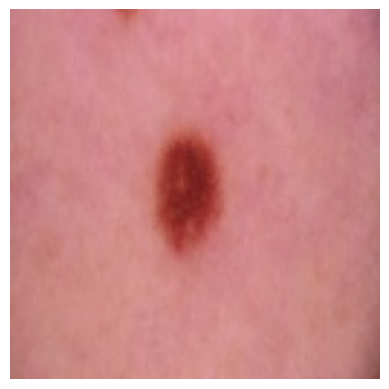

In [35]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(df['image_path'][59])

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [34]:
print(img.shape)

(128, 128, 3)


In [36]:
df.dtypes

,0
"image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target",object
image_name,object
image_path,object
